In [2]:
from google.colab import files
uploaded = files.upload()

Saving Inappapropriate_messages.csv to Inappapropriate_messages.csv


In [3]:
import pandas as pd

data = pd.read_csv('Inappapropriate_messages.csv')
data.head()

,text,inappropriate
0,"Бедный Ниссон, его бесконечных детей то похища...",0.9526
1,Все кто лишился девстенности после NUMBER - ом...,0.9972
2,Не знаю сам почему её туда отправили. Не торга...,0.0217
3,Проституция легальнаНелегальное предпринимател...,0.9986
4,"Я бы повстречался с порноактрисой, только я не...",0.9998


In [4]:
data['label'] = (data['inappropriate'] >= 0.5).astype(int)
data.head()

,text,inappropriate,label
0,"Бедный Ниссон, его бесконечных детей то похища...",0.9526,1
1,Все кто лишился девстенности после NUMBER - ом...,0.9972,1
2,Не знаю сам почему её туда отправили. Не торга...,0.0217,0
3,Проституция легальнаНелегальное предпринимател...,0.9986,1
4,"Я бы повстречался с порноактрисой, только я не...",0.9998,1


In [ ]:
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

# Подготовка данных
train_df, val_df = train_test_split(data[['text', 'label']], test_size=0.2, random_state=42, stratify=data['label'])


ds = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'validation': Dataset.from_pandas(val_df.reset_index(drop=True))
})

# Загрузка токенизатора и модели
MODEL_NAME = "deepvk/RuModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=False, max_length=512)

tokenized_datasets = ds.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Загружаем модель для классификации
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

Map:   0%|          | 0/99677 [00:00<?, ? examples/s]

Map:   0%|          | 0/24920 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: deepvk/RuModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ModernBertForSequenceClassification(
  (model): ModernBertModel(
    (embeddings): ModernBertEmbeddings(
      (tok_embeddings): Embedding(50368, 768, padding_idx=50283)
      (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0): ModernBertEncoderLayer(
        (attn_norm): Identity()
        (attn): ModernBertAttention(
          (Wqkv): Linear(in_features=768, out_features=2304, bias=False)
          (Wo): Linear(in_features=768, out_features=768, bias=False)
          (out_drop): Identity()
        )
        (mlp_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): ModernBertMLP(
          (Wi): Linear(in_features=768, out_features=2304, bias=False)
          (act): GELUActivation()
          (drop): Dropout(p=0.0, inplace=False)
          (Wo): Linear(in_features=1152, out_features=768, bias=False)
        )
      )
      (1-21): 21 x ModernBertEncoderLayer(
       

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted")
    }


training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    report_to="none",
    fp16=torch.cuda.is_available(),
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.039462,1.037727,0.847793,0.846294
1000,0.126037,0.883666,0.852287,0.852112
1500,0.119774,0.684823,0.855538,0.854662
2000,0.233082,0.333149,0.860233,0.856682
2500,0.329458,0.330146,0.862400,0.856290
3000,0.308447,0.299375,0.867175,0.865277
3500,0.302115,0.296048,0.874077,0.872894
4000,0.296358,0.297963,0.874037,0.874698
4500,0.295324,0.298759,0.872552,0.866979
5000,0.289330,0.283622,0.878652,0.877304


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6230, training_loss=0.24308796541266037, metrics={'train_runtime': 2706.929, 'train_samples_per_second': 36.823, 'train_steps_per_second': 2.302, 'total_flos': 4598163745689192.0, 'train_loss': 0.24308796541266037, 'epoch': 1.0})

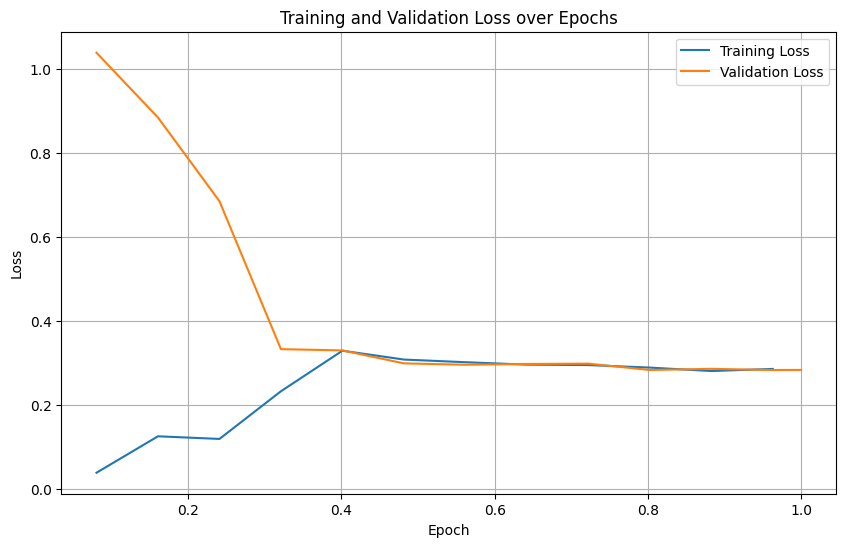

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

train_metrics = []
eval_metrics = []
for log in trainer.state.log_history:
    if 'loss' in log and 'learning_rate' in log:
        train_metrics.append(log)
    elif 'eval_loss' in log:
        eval_metrics.append(log)


train_loss_values = [m['loss'] for m in train_metrics]
train_epochs_values = [m['epoch'] for m in train_metrics]

s
eval_loss_values = [m['eval_loss'] for m in eval_metrics]
eval_epochs_values = [m['epoch'] for m in eval_metrics]

plt.figure(figsize=(10, 6))
sns.lineplot(x=train_epochs_values, y=train_loss_values, label='Training Loss')
sns.lineplot(x=eval_epochs_values, y=eval_loss_values, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

def predict_toxicity(text):
    result = classifier(text)
    predicted_label = int(result[0]['label'].split('_')[1])
    return "Токсичный" if predicted_label == 1 else "Нетоксичный"

example_text1 = "животные едят других животных"
example_text2 = "животное"
example_text3 = "ты животное"

print(f"Текст: '{example_text1}' - Предсказание: {predict_toxicity(example_text1)}")
print(f"Текст: '{example_text2}' - Предсказание: {predict_toxicity(example_text2)}")
print(f"Текст: '{example_text3}' - Предсказание: {predict_toxicity(example_text3)}")

Текст: 'животные едят других животных' - Предсказание: Нетоксичный
Текст: 'животное' - Предсказание: Нетоксичный
Текст: 'ты животное' - Предсказание: Токсичный


In [ ]:
import os
import shutil

output_dir = "./toxic_model"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)


shutil.make_archive(output_dir, 'zip', output_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Модель и токенизатор сохранены и заархивированы в ./toxic_model.zip
